##  Importing Necessary Libraries

In [56]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

import re
import pickle

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

## Loading and Preparing the Dataset

In [59]:
# Load datasets
data_0 = pd.read_csv("True.csv", usecols=["text"])
data_1 = pd.read_csv("Fake.csv", usecols=["text"])

# Assign classes
data_0["label"] = 0
data_1["label"] = 1

# Combine datasets
data = pd.concat([data_0, data_1])

## Shuffling Data and Resetting Index for Consistency

In [85]:
# Shuffle the data and reset the index
data = data.sample(frac=1)
data.reset_index(inplace=True)
data.drop(['index'], axis=1, inplace=True)
data.head()

,text,label
0,dubai reuters iranian president hassan rouhani...,0
1,following covfefe gate trump made absolute foo...,1
2,trump administration official mulling executiv...,1
3,dhaka yangon reuters united nation appealed th...,0
4,washington reuters u democratic presidential c...,0


In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB


## 4. Text Cleaning and Preprocessing

In [63]:
# Download necessary NLTK resources
nltk.download("wordnet")
nltk.download("stopwords")

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stopword = set(stopwords.words("english"))

# Define the cleaning function
def clean_text(data):
    data = data.lower()  # Convert to lowercase
    
    # Replace non-alphabetic characters with spaces
    data = re.sub("[^a-z]", " ", data)
    
    # Replace multiple spaces with a single space
    data = re.sub(r'\s+', " ", data)

    # Split the text into words
    words = data.split()
    lemmatized_words = [lemmatizer.lemmatize(word) 
                        for word in words if word not in stopword]

    # Rejoin lemmatized words into a single string
    data = " ".join(lemmatized_words)
    return data
    
data["text"] = data["text"].apply(clean_text)

# Output the result
print(data.head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\krish\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\krish\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  label
0  trey gowdy rip clinton case using private e ma...      1
1  great july th president trump attending nation...      1
2  hannah cohen year old brain tumor patient flyi...      1
3  read anything supreme court today likely uphel...      1
4  washington reuters lockheed martin corp awarde...      0


## 5. Feature Extraction using TF-IDF Vectorizer

In [10]:
# Separate text and class labels
X = data["text"]
Y = data["label"]

# # Convert text data to numerical form using TF-IDF
vectorizer = TfidfVectorizer(max_features=20000, lowercase=False, ngram_range=(1, 2))

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state= 42)

# Transform text data
xv_train_data = vectorizer.fit_transform(x_train).toarray()
xv_test_data = vectorizer.transform(x_test).toarray()

print("Train data Shape:", xv_train_data.shape)
print("Test data Shape:", xv_test_data.shape)

# Getting Feature names and converting into dataFrame
columns = vectorizer.get_feature_names_out()
training_data = pd.DataFrame(xv_train_data, columns=columns)
testing_data = pd.DataFrame(xv_test_data, columns=columns)

# Saving Vectorizer using pickle
with open("Vectorizer.pkl","wb") as file:
    pickle.dump(vectorizer, file)

Train data Shape: (35918, 20000)
Test data Shape: (8980, 20000)


## 6. Initializing and Training Machine Learning Models

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Initialize classifiers
mnNB_clf = MultinomialNB()
lr_clf = LogisticRegression()
rfc_clf = RandomForestClassifier()

In [13]:
accuracy_scores = {}
def model_performance(clf_name):
    clf = clf_name
    model_name = clf.__class__.__name__  # getting classifier name
    pred = clf.predict(testing_data)
    score = accuracy_score(y_test, pred)
    accuracy_scores[model_name] = score
    report = classification_report(y_test, pred)
    print(f"{model_name} model got {round(score,2)*100} % accuracy !!")
    print("   ")
    print(report)

In [14]:
# Fitting MultiNomial NB classifier
mnNB_clf.fit(training_data, y_train)

pickle.dump(mnNB_clf, open("MultiNomial_clf.pkl","wb"))
model_performance(mnNB_clf)

MultinomialNB model got 95.0 % accuracy !!
   
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      4354
           1       0.94      0.96      0.95      4626

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



In [15]:
# Fitting LogisticRegression
lr_clf.fit(training_data, y_train)

pickle.dump(lr_clf , open("LogisticRegression_clf.pkl","wb"))
model_performance(lr_clf)

LogisticRegression model got 99.0 % accuracy !!
   
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4354
           1       0.99      0.99      0.99      4626

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [18]:
# Fitting Random Forest classifier
rfc_clf.fit(training_data,y_train)

pickle.dump(rfc_clf, open("RandomForest_clf.pkl","wb"))
model_performance(rfc_clf)

RandomForestClassifier model got 100.0 % accuracy !!
   
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4354
           1       1.00      1.00      1.00      4626

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



## 7. Evaluating Model Performance with Visualization

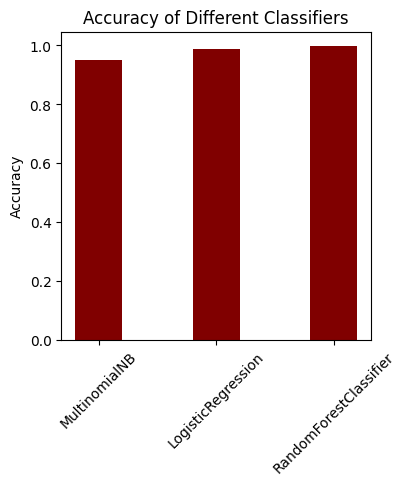

In [45]:
# Visualize the accuracy scores
models = list(accuracy_scores.keys())
scores = list(accuracy_scores.values())
fig = plt.figure(figsize=(4,4))
plt.bar(models,scores,color="maroon",width = 0.4)
plt.title("Accuracy of Different Classifiers")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

## 8. Selecting the Best Model

In [49]:
# Select the model with the highest accuracy score
best_model = max(accuracy_scores.keys(), key= accuracy_scores.get)
print(f"Best performing model: {best_model}")
print(f"Accuracy: {accuracy_scores[best_model]:.2f}")

Best performing model: RandomForestClassifier
Accuracy: 1.00


## 9. User Input Testing

In [ ]:
# Function for predicting user input
def user_input_prediction(text):
    text = clean_text(pd.Series([text]))  # Clean user input
    text = vectorizer.transform(text).toarray()  # Vectorize input
    text = pd.DataFrame(text, columns=vectorizer.get_feature_names_out())
    
    # Predict with the best model
    result = best_model.predict(text)
    return result

# Continuous user input for spam detection
print("Enter 1 to close the program")
while True:
    text = input("Enter your text: ")
    if text == "1":
        break
    elif not text.strip():
        print("Please enter a valid text!")
        continue
    else:
        res = user_input_prediction(text)
        result_message = "The given Text is SPAM !!!" if res == 1 else "Not Spam"
        print(result_message)

Enter 1 to close the program


Enter your text:   


Please enter a valid text!


Enter your text:    


Please enter a valid text!
